# **COLMAP :**

NOTE : 
- database.db
    - COLMAP stores the extracted information here

- sparse_path
    - COLMAP's SfM/Mapper will save the sparse reconstruction here.

- dense_path
    - This is where the dense reconstruction workspace goes.

In [1]:
from pathlib import Path
import cv2
# Project paths
PROJECT_ROOT = Path("..")

VIDEO_PATH = PROJECT_ROOT / "video"
FRAMES_PATH = PROJECT_ROOT / "data" / "frames"

COLMAP_PATH = PROJECT_ROOT / "data" / "colmap"
DATABASE_PATH = COLMAP_PATH / "database.db"
SPARSE_PATH = COLMAP_PATH / "sparse"
DENSE_PATH = COLMAP_PATH / "dense"

# Create required directories
COLMAP_PATH.mkdir(parents=True, exist_ok=True)
SPARSE_PATH.mkdir(parents=True, exist_ok=True)
DENSE_PATH.mkdir(parents=True, exist_ok=True)

print("Frames :", FRAMES_PATH)
print("Database:", DATABASE_PATH)
print("Sparse :", SPARSE_PATH)
print("Dense  :", DENSE_PATH)

Frames : ..\data\frames
Database: ..\data\colmap\database.db
Sparse : ..\data\colmap\sparse
Dense  : ..\data\colmap\dense


In [85]:
# # * extracted frames
image_files = sorted(FRAMES_PATH.glob("*.jpg"))

print(f"Number of frames: {len(image_files)}")

if image_files:
    print(f"First frame: {image_files[0]}")
    print(f"Last frame : {image_files[-1]}")

Number of frames: 199
First frame: ..\data\frames\frame_000000.jpg
Last frame : ..\data\frames\frame_000198.jpg


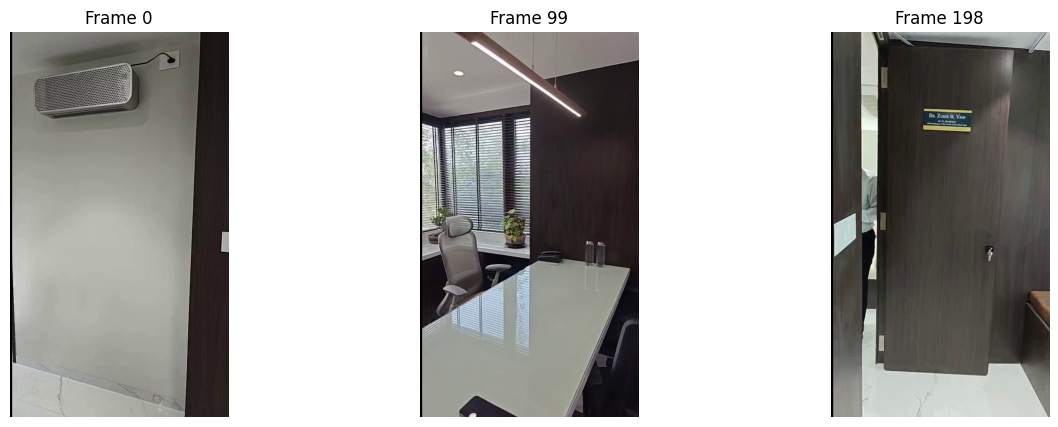

In [86]:
# # * looking into few images :

import matplotlib.pyplot as plt

indices = [0, len(image_files)//2, len(image_files)-1]

plt.figure(figsize=(15, 5))

for i, index in enumerate(indices):
    image = cv2.imread(str(image_files[index]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Frame {index}")

plt.show()

# **Run Feature Extraction :**

In [87]:
import subprocess

In [88]:
import subprocess

COLMAP = r"C:\Users\sejal\Downloads\colmap-x64-windows-cuda\bin\colmap.exe"
DATABASE_PATH = r"D:\3D Reconstruction - 2\data\colmap\database.db"
IMAGE_PATH = r"D:\3D Reconstruction - 2\data\frames"

command = [
    COLMAP,
    "feature_extractor",
    "--database_path", DATABASE_PATH,
    "--image_path", IMAGE_PATH,
    "--FeatureExtraction.use_gpu", "1",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)


I20260903 12:05:05.123224 26408 feature_extraction.cc:498] === Feature extraction ===
I20260903 12:05:05.125324  9504 sift.cc:759] Creating SIFT GPU feature extractor
I20260903 12:05:05.250676 12912 feature_extraction.cc:270] Processed file [1/199]
I20260903 12:05:05.250736 12912 feature_extraction.cc:273]   Name:            frame_000000.jpg
I20260903 12:05:05.250770 12912 feature_extraction.cc:282]   Dimensions:      408 x 720
I20260903 12:05:05.250778 12912 feature_extraction.cc:285]   Camera:          #1 - SIMPLE_RADIAL
I20260903 12:05:05.250786 12912 feature_extraction.cc:289]   Focal Length:    864.00px
I20260903 12:05:05.250800 12912 feature_extraction.cc:294]   Features:        174 (SIFT)
I20260903 12:05:05.260565 12912 feature_extraction.cc:270] Processed file [2/199]
I20260903 12:05:05.260630 12912 feature_extraction.cc:273]   Name:            frame_000001.jpg
I20260903 12:05:05.260641 12912 feature_extraction.cc:282]   Dimensions:      408 x 720
I20260903 12:05:05.260648 129

# **Run feature matching :**

In [89]:
command = [
    COLMAP,
    # "sequential_matcher",
    "exhaustive_matcher",
    # "--SequentialMatching.overlap", "20",
    "--database_path", DATABASE_PATH,
    "--FeatureMatching.use_gpu", "1",
    "--FeatureMatching.gpu_index", "0",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"COLMAP matching failed with exit code {result.returncode}"
    )

print("Feature matching completed successfully.")


I20260903 12:05:07.879519 20956 feature_matching.cc:196] === Feature matching & geometric verification ===
I20260903 12:05:07.960221 25960 feature_matching_utils.cc:79] Bind FeatureMatcherWorker to GPU device 0
I20260903 12:05:07.960988 25960 sift.cc:1680] Creating SIFT GPU feature matcher
I20260903 12:05:07.961724 20956 pairing.cc:179] Generating exhaustive image pairs...
I20260903 12:05:07.961758 20956 pairing.cc:212] Processing block [1/4, 1/4]
I20260903 12:05:08.145082 20956 feature_matching.cc:218] in 0.183s
I20260903 12:05:08.145138 20956 pairing.cc:212] Processing block [1/4, 2/4]
I20260903 12:05:08.326556 20956 feature_matching.cc:218] in 0.181s
I20260903 12:05:08.326612 20956 pairing.cc:212] Processing block [1/4, 3/4]
I20260903 12:05:08.547356 20956 feature_matching.cc:218] in 0.221s
I20260903 12:05:08.547413 20956 pairing.cc:212] Processing block [1/4, 4/4]
I20260903 12:05:08.717558 20956 feature_matching.cc:218] in 0.170s
I20260903 12:05:08.717610 20956 pairing.cc:212] Pro

# **Sparse Reconstruction / Mapper :**

In [90]:
DATABASE_PATH = r"D:\3D Reconstruction - 2\data\colmap\database.db"
IMAGE_PATH = r"D:\3D Reconstruction - 2\data\frames"
SPARSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\sparse"

Path(SPARSE_PATH).mkdir(parents=True, exist_ok=True)

command = [
    COLMAP,
    "mapper",
    "--database_path", DATABASE_PATH,
    "--image_path", IMAGE_PATH,
    "--output_path", SPARSE_PATH,
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"COLMAP mapper failed with exit code {result.returncode}"
    )

print("Sparse reconstruction completed successfully.")


I20260903 12:05:13.275061  3980 incremental_pipeline.cc:353] Loading database
I20260903 12:05:13.275940  3980 database_cache.cc:73] Loading rigs...
I20260903 12:05:13.276096  3980 database_cache.cc:83]  199 in 0.000s
I20260903 12:05:13.276112  3980 database_cache.cc:91] Loading cameras...
I20260903 12:05:13.276200  3980 database_cache.cc:109]  199 in 0.000s
I20260903 12:05:13.276209  3980 database_cache.cc:117] Loading frames...
I20260903 12:05:13.276439  3980 database_cache.cc:127]  199 in 0.000s
I20260903 12:05:13.276452  3980 database_cache.cc:135] Loading matches...
I20260903 12:05:13.286383  3980 database_cache.cc:140]  4619 in 0.010s
I20260903 12:05:13.286441  3980 database_cache.cc:148] Loading images...
I20260903 12:05:13.292454  3980 database_cache.cc:245]  199 in 0.006s (connected 199, loaded 199)
I20260903 12:05:13.292509  3980 database_cache.cc:259] Loading pose priors...
I20260903 12:05:13.292529  3980 database_cache.cc:267]  0 in 0.000s
I20260903 12:05:13.292536  3980 da

In [91]:
from pathlib import Path

sparse_model = Path("../data/colmap/sparse/0")

print("Sparse model exists:", sparse_model.exists())

if sparse_model.exists():
    for file in sparse_model.iterdir():
        print(file.name)

Sparse model exists: True
cameras.bin
frames.bin
images.bin
points3D.bin
project.ini
rigs.bin


In [92]:
# stop

In [93]:
import os

len(os.listdir(SPARSE_PATH))

2

In [94]:
import subprocess
from pathlib import Path

COLMAP = r"C:\Users\sejal\Downloads\colmap-x64-windows-cuda\bin\colmap.exe"

SPARSE_PATH = Path("../data/colmap/sparse")
TXT_ROOT = Path("../data/colmap/sparse_txt")

TXT_ROOT.mkdir(parents=True, exist_ok=True)


def get_model_stats(model_id):
    model_path = SPARSE_PATH / str(model_id)
    txt_path = TXT_ROOT / str(model_id)

    txt_path.mkdir(parents=True, exist_ok=True)

    command = [
        COLMAP,
        "model_converter",
        "--input_path", str(model_path.resolve()),
        "--output_path", str(txt_path.resolve()),
        "--output_type", "TXT",
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr)
        return None

    # Count registered images
    images_file = txt_path / "images.txt"
    points_file = txt_path / "points3D.txt"

    with open(images_file, "r") as f:
        image_lines = [
            line for line in f
            if line.strip() and not line.startswith("#")
        ]

    # Each image uses two lines in images.txt
    registered_images = len(image_lines) // 2

    # Count 3D points
    with open(points_file, "r") as f:
        point_lines = [
            line for line in f
            if line.strip() and not line.startswith("#")
        ]

    num_points = len(point_lines)

    return registered_images, num_points


best_model_id=0
best_num_points=0
best_num_image=0

for model_id in range(len(os.listdir(SPARSE_PATH))):
    stats = get_model_stats(model_id)

    if stats:
        registered_images, num_points = stats

        if num_points > best_num_points :
            best_num_points=num_points
            best_model_id=model_id
            best_num_image=registered_images

        print(
            f"Model {model_id}: "
            f"{registered_images} images, "
            f"{num_points} 3D points"
        )



print("="*20)
print(
    f"Best Model : { best_model_id} \n"
    f"Best num Points :{best_num_points}\n"
    f"Best Register Image :{best_num_image}\n"
)

Model 0: 168 images, 2230 3D points
Model 1: 28 images, 422 3D points
Best Model : 0 
Best num Points :2230
Best Register Image :168



## **Convert sparse model to PLY :**

- COLMAP's points3D.bin is its internal format. For visualization and our final deliverable, we want a .ply.

In [95]:
SPARSE_MODEL = rf"D:\3D Reconstruction\data\colmap\sparse\{best_model_id}"
SPARSE_MODEL

'D:\\3D Reconstruction\\data\\colmap\\sparse\\0'

In [96]:
SPARSE_MODEL = rf"D:\3D Reconstruction - 2\data\colmap\sparse\{best_model_id}"

SPARSE_PLY = r"D:\3D Reconstruction - 2\data\colmap\sparse.ply"

command = [
    COLMAP,
    "model_converter",
    "--input_path", SPARSE_MODEL,
    "--output_path", SPARSE_PLY,
    "--output_type", "PLY",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"Sparse model conversion failed: {result.returncode}"
    )

print(f"Sparse point cloud saved to: {SPARSE_PLY}")



Sparse point cloud saved to: D:\3D Reconstruction - 2\data\colmap\sparse.ply


In [97]:
from pathlib import Path

sparse_ply = Path("../data/colmap/sparse.ply")

print("Exists:", sparse_ply.exists())
print("Size:", sparse_ply.stat().st_size, "bytes")

Exists: True
Size: 33638 bytes


In [98]:
sparse_ply

WindowsPath('../data/colmap/sparse.ply')

In [99]:
import open3d as o3d


# dense_pcd = o3d.io.read_point_cloud(
#     "../results/colmap/exp_30fps_exp1/fused.ply"
# )
sparse_pcd = o3d.io.read_point_cloud(
    sparse_ply
)

print(sparse_pcd)
print("Dense points:", len(sparse_pcd.points))

PointCloud with 2230 points.
Dense points: 2230


In [100]:
o3d.visualization.draw_geometries([sparse_pcd])


In [101]:
!pip install open3d

In [102]:
import open3d as o3d

pcd = o3d.io.read_point_cloud("../data/colmap/sparse.ply")

print(pcd)
print("Number of points:", len(pcd.points))

PointCloud with 2230 points.
Number of points: 2230


# **Dense Reconstruction :**

In [103]:
from pathlib import Path

DENSE_PATH = Path("../data/colmap/dense")

DENSE_PATH.mkdir(parents=True, exist_ok=True)

print("Dense workspace:", DENSE_PATH.resolve())

Dense workspace: D:\3D Reconstruction - 2\data\colmap\dense


In [104]:
import subprocess


IMAGE_PATH = r"D:\3D Reconstruction - 2\data\frames"

SPARSE_MODEL = rf"D:\3D Reconstruction - 2\data\colmap\sparse\{best_model_id}"

SPARSE_PLY = r"D:\3D Reconstruction - 2\data\colmap\sparse.ply"

DENSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\dense"

command = [
    COLMAP,
    "image_undistorter",
    "--image_path", IMAGE_PATH,
    "--input_path", SPARSE_MODEL,
    "--output_path", DENSE_PATH,
    "--output_type", "COLMAP",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"Image undistortion failed: {result.returncode}"
    )

print("Image undistortion completed successfully.")


I20260903 12:17:15.300739 15956 image.cc:377] === Reading reconstruction ===
I20260903 12:17:15.320403 15956 image.cc:380] => Reconstruction with 168 images and 2230 points
I20260903 12:17:15.320525 15956 undistorters.cc:167] === Image undistortion ===
I20260903 12:17:15.323081 15956 undistorters.cc:209] Undistorting image [1/168]
I20260903 12:17:15.368019 15956 undistorters.cc:209] Undistorting image [2/168]
I20260903 12:17:15.371577 15956 undistorters.cc:209] Undistorting image [3/168]
I20260903 12:17:15.382029 15956 undistorters.cc:209] Undistorting image [4/168]
I20260903 12:17:15.382081 15956 undistorters.cc:209] Undistorting image [5/168]
I20260903 12:17:15.382095 15956 undistorters.cc:209] Undistorting image [6/168]
I20260903 12:17:15.382105 15956 undistorters.cc:209] Undistorting image [7/168]
I20260903 12:17:15.382116 15956 undistorters.cc:209] Undistorting image [8/168]
I20260903 12:17:15.382126 15956 undistorters.cc:209] Undistorting image [9/168]
I20260903 12:17:15.382136 

# **PatchMatch Stereo :**

In [105]:
import subprocess


DENSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\dense"

command = [
    COLMAP,
    "patch_match_stereo",
    "--workspace_path", DENSE_PATH,
    "--workspace_format", "COLMAP",
    "--PatchMatchStereo.geom_consistency", "true",
    "--PatchMatchStereo.gpu_index", "0",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"PatchMatch Stereo failed with exit code {result.returncode}"
    )

print("PatchMatch Stereo completed successfully.")


I20260903 12:17:15.976610 18408 patch_match.cc:210] Reading workspace...
I20260903 12:17:15.996880 18408 patch_match.cc:240] Reading configuration...
I20260903 12:17:16.035097 18408 patch_match.cc:371] Configuration has 168 problems...
I20260903 12:17:16.036062 18628 patch_match.cc:419] === Processing view 1 / 168 for frame_000023.jpg ===
I20260903 12:17:16.036113 18628 patch_match.cc:466] Reading inputs...
I20260903 12:17:16.058707 18628 patch_match.cc:56] --- PatchMatch::Problem ---
I20260903 12:17:16.058759 18628 patch_match.cc:57] ref_image_idx: 0
I20260903 12:17:16.058772 18628 patch_match.cc:64] src_image_idxs: 46 41 48 47 40 49 50 6 8 7 9 42 44 43 45
I20260903 12:17:16.058779 18628 patch_match_options.cc:46] --- PatchMatchOptions ---
I20260903 12:17:16.058784 18628 patch_match_options.cc:47] max_image_size: -1
I20260903 12:17:16.058791 18628 patch_match_options.cc:48] gpu_index: 0
I20260903 12:17:16.058796 18628 patch_match_options.cc:49] depth_min: 0.241546
I20260903 12:17:16.

RuntimeError: PatchMatch Stereo failed with exit code 3221226505

# **COLMAP dense-reconstruction step: Stereo Fusion :**

In [ ]:
import subprocess


DENSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\dense"

command = [
    COLMAP,
    "stereo_fusion",
    "--workspace_path", DENSE_PATH,
    "--workspace_format", "COLMAP",
    "--output_path", DENSE_PATH + r"\fused.ply",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"Stereo Fusion failed with exit code {result.returncode}"
    )

print("Dense point cloud created successfully.")
print("Output:", DENSE_PATH + r"\fused.ply")


I20260903 12:03:37.205535 28240 fusion.cc:79] --- StereoFusion::Options ---
I20260903 12:03:37.206518 28240 fusion.cc:80] mask_path: ""
I20260903 12:03:37.206534 28240 fusion.cc:81] max_image_size: -1
I20260903 12:03:37.206541 28240 fusion.cc:82] min_num_pixels: 5
I20260903 12:03:37.206547 28240 fusion.cc:83] max_num_pixels: 10000
I20260903 12:03:37.206554 28240 fusion.cc:84] max_traversal_depth: 100
I20260903 12:03:37.206560 28240 fusion.cc:85] max_reproj_error: 2
I20260903 12:03:37.206572 28240 fusion.cc:86] max_depth_error: 0.01
I20260903 12:03:37.206582 28240 fusion.cc:87] max_normal_error: 10
I20260903 12:03:37.206588 28240 fusion.cc:88] check_num_images: 50
I20260903 12:03:37.206595 28240 fusion.cc:89] use_cache: 0
I20260903 12:03:37.206605 28240 fusion.cc:90] cache_size: 32
I20260903 12:03:37.206614 28240 fusion.cc:93] bbox_min: -3.40282e+38 -3.40282e+38 -3.40282e+38
I20260903 12:03:37.206632 28240 fusion.cc:94] bbox_max: 3.40282e+38 3.40282e+38 3.40282e+38
I20260903 12:03:37.2

In [15]:
path_dens=r"D:\3D Reconstruction\best_results\colmap\dense_30fps_sequential.ply"

In [16]:
import open3d as o3d


# dense_pcd = o3d.io.read_point_cloud(
#     "../results/colmap/exp_30fps_exp1/fused.ply"
# )
# dense_pcd = o3d.io.read_point_cloud(
#     r"D:\3D Reconstruction - 2\data\colmap\dense\fused.ply"
# )
dense_pcd = o3d.io.read_point_cloud(
    path_dens
)

print(dense_pcd)
print("Dense points:", len(dense_pcd.points))

PointCloud with 368377 points.
Dense points: 368377


In [17]:
o3d.visualization.draw_geometries([dense_pcd])